In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

When applying Deep Potential to real Gaia data, there is usually a missing "hole" centered on the Sun, due to Gaia's bright limit. The purpose of this notebook is to demonstrate that one can determine the mass inside this hole using Gauss' law. We measure the potential on the entire boundary of the hole, which theoretically contains information about the mass inside the bounded volume.

# Create arbitrary potential model

We will begin by setting up the simplest possible potential: the potential of a point source at the origin (unit mass, $G = 1$).

$$
  \Phi = -\frac{1}{r} \, .
$$

In [81]:
def potential(x):
    r = tf.norm(x, axis=-1)
    return -1 / r

# Calculate mass from Gauss' law

Gauss' law applied to gravity:

$$
  M = -\frac{1}{4\pi G} \int \nabla \Phi \cdot \mathrm{d}\vec{A} \, ,
$$

where $\mathrm{d}\vec{A}$ is the surface area element. We will estimate this surface integral by evaluating the integrand at points randomly drawn from the surface of a sphere.

In [82]:
def pick_sphere_points(n_points, n_dim=3, rng=None):
    """Pick n_points uniformly on the surface of a unit sphere."""
    if rng is None:
        rng = tf.random.Generator.from_non_deterministic_state()
    x = rng.normal([n_points, n_dim], dtype=tf.float32)
    x = x / tf.norm(x, axis=-1, keepdims=True)
    return x

In [91]:
def calc_enclosed_mass(potential_fn, x0, r,
                       n_points=1024, return_points=False):
    """Calculate the enclosed mass using Gauss's law."""
    # Pick points on sphere
    dx = pick_sphere_points(n_points, n_dim=3)
    x = x0 + r * dx

    # Compute acceleration at each point
    with tf.GradientTape() as g:
        g.watch(x)
        phi = potential_fn(x)
    grad_phi = g.gradient(phi, x)

    # Average flux over sphere
    avg_flux = tf.reduce_mean(tf.reduce_sum(grad_phi*dx, axis=-1))
    mass_enc = avg_flux * r**2

    if return_points:
        # Also return points, potentials and accelerations
        a = -grad_phi
        return mass_enc, x, phi, a
    
    return mass_enc

In [113]:
m,x,phi,a = calc_enclosed_mass(
    potential,
    x0=tf.constant([0.6,0.,0.],dtype=tf.float32),
    r=1.0,
    n_points=1024*16,
    return_points=True
)

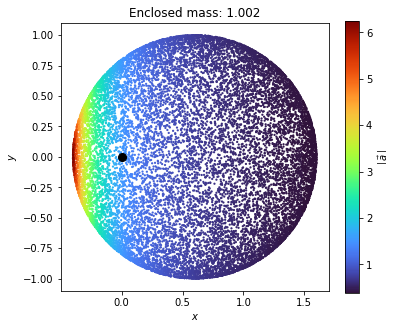

In [116]:
fig,ax = plt.subplots(1,1, figsize=(6,5))
ax.set_aspect('equal')
im = ax.scatter(
    x[:,0], x[:,1],
    c=tf.norm(a, axis=-1),
    s=5, edgecolors='none',
    cmap='turbo'
)
ax.scatter([0], [0], c='k', s=64)
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
fig.colorbar(im, ax=ax, label=r'$\left|\,\vec{a}\,\right|$')
ax.set_title(f'Enclosed mass: {m:.3f}')
plt.show()